In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, shapiro, mannwhitneyu
from scipy.stats import chi2_contingency, norm
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv(r'C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\Washington-Post-police-shootings_common_names.csv')


In [6]:
df['race'].value_counts(normalize=True) * 100  # for percentage distribution


race
W        45.813838
B        24.499751
H        16.874067
U         9.109009
A         1.811847
N         1.403683
O         0.368342
W,B       0.039821
W,H       0.029866
B,H       0.019910
W,B,N     0.009955
N,H       0.009955
W,A       0.009955
Name: proportion, dtype: float64

Initial Missing Values:
flee                           1377
longitude                      1058
latitude                       1057
armed                           209
age                             128
city                             66
gender                            4
police_departments_involved       1
year                              0
race                              0
state                             0
mental_illness                    0
body_camera                       0
name                              0
day                               0
month                             0
date                              0
dtype: int64

Post-Imputation Missing Values:
flee                           1377
longitude                      1058
latitude                       1057
city                             66
gender                            4
police_departments_involved       1
body_camera                       0
mental_illness                    0
state                         

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


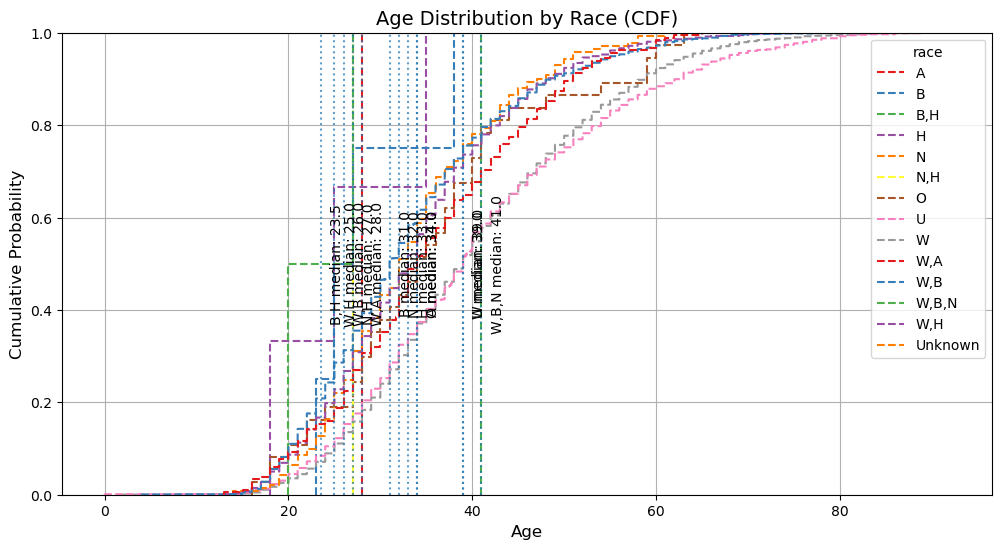


Kruskal-Wallis Test Results:
H-statistic = 768.50, p = 0.0000


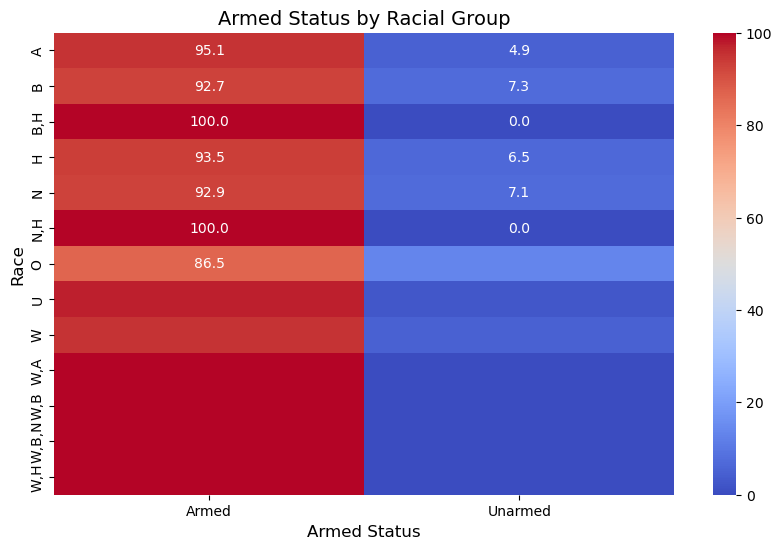


Chi-square Test Results:
χ² = 42.51, p = 0.0000


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


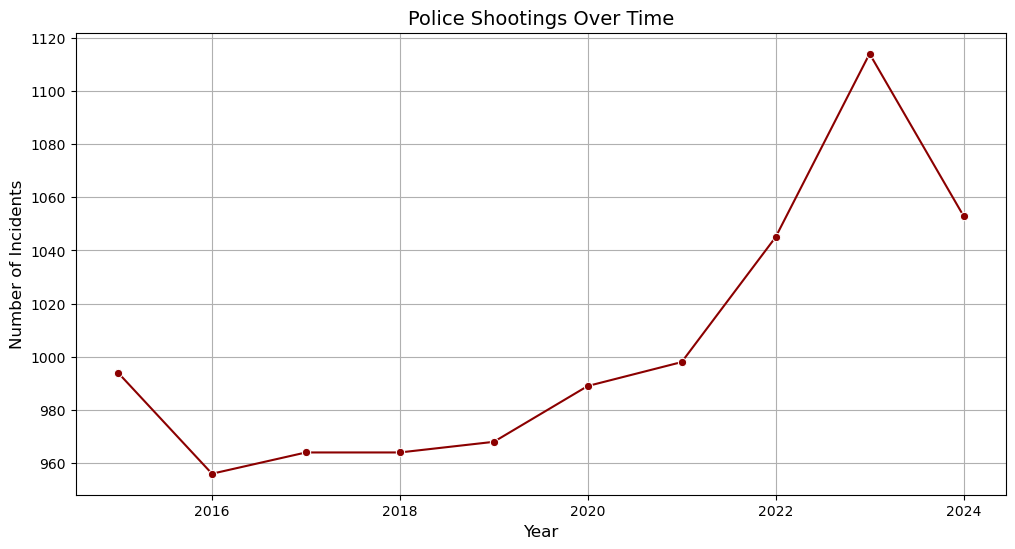

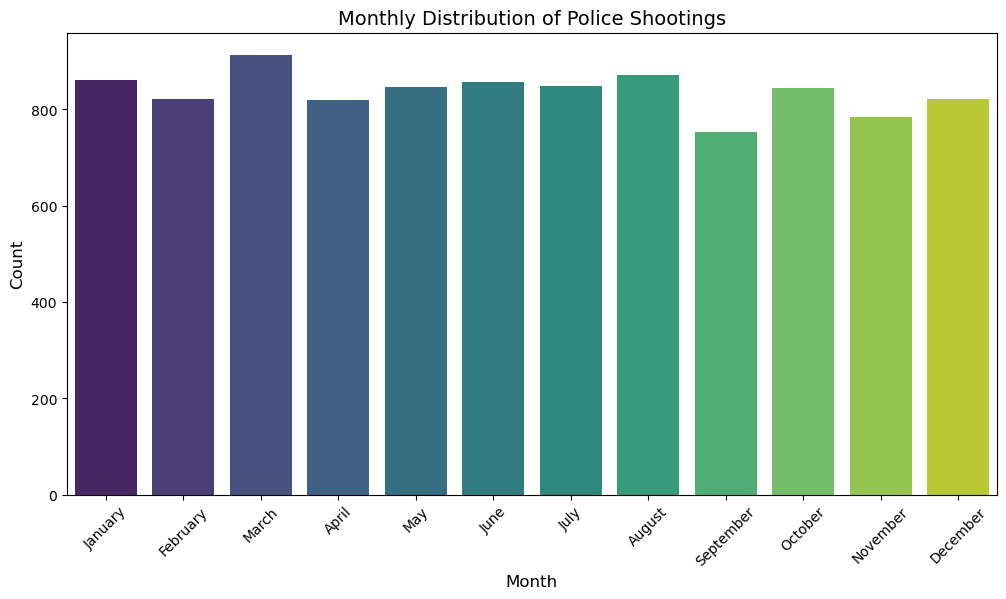

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


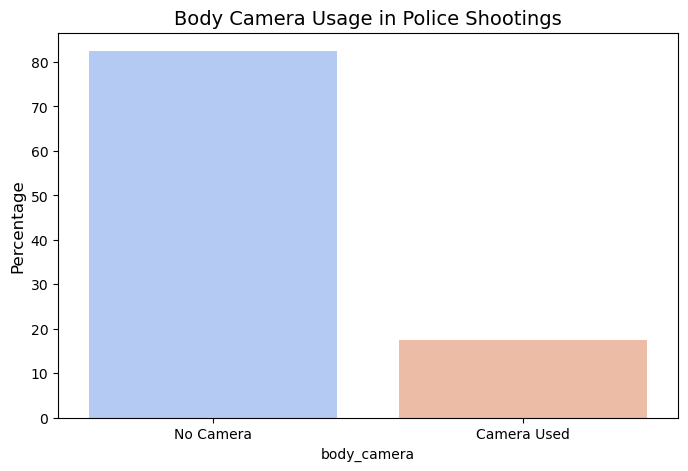

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


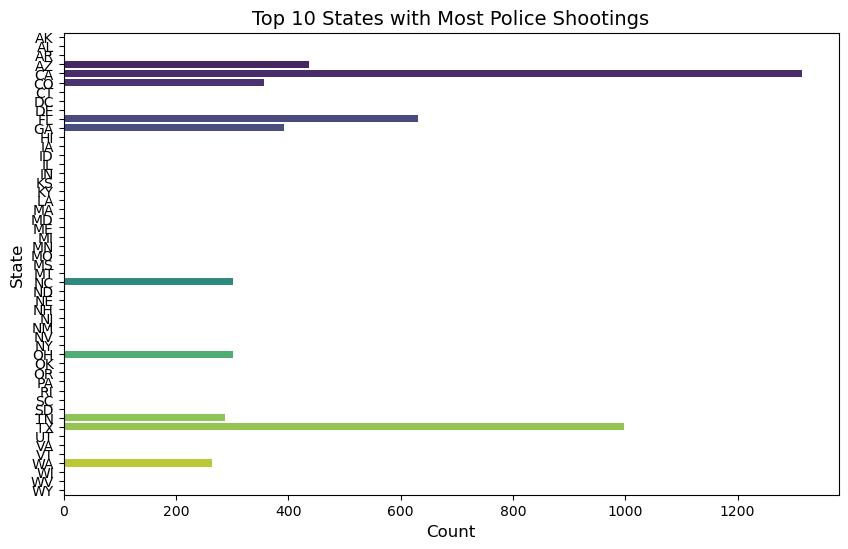


Normality Tests:
B: W = 0.947, p = 0.0000
W: W = 0.977, p = 0.0000
A: W = 0.983, p = 0.0235
H: W = 0.969, p = 0.0000
U: W = 0.966, p = 0.0000
O: W = 0.946, p = 0.0708
N: W = 0.969, p = 0.0029
W,B: W = 0.840, p = 0.1966

Monte Carlo Results:
B: p = 0.5002
W: p = 0.4960
A: p = 0.4915
H: p = 0.4920
U: p = 0.4932
O: p = 0.5365
N: p = 0.5036
W,B: p = 0.4736


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu, kruskal, chi2_contingency
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.stats.proportion import proportions_ztest

# ----------------------------
# 1. Load and Prepare Data
# ----------------------------
df = pd.read_csv(r'C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\Washington-Post-police-shootings_common_names.csv')

# ----------------------------
# 2. Missing Value Handling
# ----------------------------
# Initial missingness analysis
print("Initial Missing Values:")
print(df.isnull().sum().sort_values(ascending=False))

# Handle categorical variables
categorical_cols = ['race', 'armed', 'state', 'body_camera']
df[categorical_cols] = df[categorical_cols].astype("category")  # Convert to categorical

for col in categorical_cols:
    if col == 'race':  # Special handling for sensitive feature
        df[col] = df[col].cat.add_categories('Unknown').fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Handle numerical variables with MICE
numerical_cols = ['age']
encoder = OrdinalEncoder()
encoded_cats = encoder.fit_transform(df[categorical_cols])

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_numerical = mice_imputer.fit_transform(
    np.concatenate([df[numerical_cols].values.reshape(-1, 1), encoded_cats], axis=1)
)

df[numerical_cols] = imputed_numerical[:, :len(numerical_cols)]

print("\nPost-Imputation Missing Values:")
print(df.isnull().sum().sort_values(ascending=False))

# ----------------------------
# 3. Age Distribution Analysis
# ----------------------------
# CDF Plot with statistical results
plt.figure(figsize=(12, 6))
sns.ecdfplot(data=df, x='age', hue='race', palette='Set1', linestyle='--')
plt.title("Age Distribution by Race (CDF)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.grid(True)

# Add median markers
for race in df['race'].unique():
    median_age = df[df['race'] == race]['age'].median()
    plt.axvline(median_age, linestyle=':', alpha=0.7)
    plt.text(median_age + 1, 0.5, f'{race} median: {median_age:.1f}', 
             rotation=90, va='center')
plt.show()

# Statistical tests
age_groups = [df[df['race'] == race]['age'].dropna() for race in df['race'].unique()]
kw_stat, kw_p = kruskal(*age_groups)
print(f"\nKruskal-Wallis Test Results:\nH-statistic = {kw_stat:.2f}, p = {kw_p:.4f}")

# ----------------------------
# 4. Weapon Involvement Analysis
# ----------------------------
# Armed status analysis
df['armed_status'] = df['armed'].apply(lambda x: 'Unarmed' if x == 'unarmed' else 'Armed')

plt.figure(figsize=(10, 6))
armed_ct = pd.crosstab(df['race'], df['armed_status'], normalize='index') * 100
sns.heatmap(armed_ct, annot=True, fmt='.1f', cmap='coolwarm')  # FIXED FORMAT
plt.title("Armed Status by Racial Group", fontsize=14)
plt.xlabel("Armed Status", fontsize=12)
plt.ylabel("Race", fontsize=12)
plt.show()

# Statistical tests
chi2, p, _, _ = chi2_contingency(pd.crosstab(df['race'], df['armed_status']))
print(f"\nChi-square Test Results:\nχ² = {chi2:.2f}, p = {p:.4f}")

# ----------------------------
# 5. Temporal Trend Analysis
# ----------------------------
# Convert and analyze dates
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name()

# Yearly trends
plt.figure(figsize=(12, 6))
yearly_counts = df.groupby('year').size()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='darkred')
plt.title("Police Shootings Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.grid(True)
plt.show()

# Monthly trends
plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df, x='month', order=month_order, palette='viridis')
plt.title("Monthly Distribution of Police Shootings", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# ----------------------------
# 6. Body Camera Analysis
# ----------------------------
plt.figure(figsize=(8, 5))
body_cam_counts = df['body_camera'].value_counts(normalize=True) * 100
sns.barplot(x=body_cam_counts.index, y=body_cam_counts.values, palette='coolwarm')
plt.title("Body Camera Usage in Police Shootings", fontsize=14)
plt.ylabel("Percentage", fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Camera', 'Camera Used'])
plt.show()

# ----------------------------
# 7. State-wise Analysis
# ----------------------------
plt.figure(figsize=(10, 6))
state_counts = df['state'].value_counts().head(10)
sns.barplot(y=state_counts.index, x=state_counts.values, palette='viridis')
plt.title("Top 10 States with Most Police Shootings", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.show()

# ----------------------------
# 8. Advanced Statistical Tests
# ----------------------------
# Age normality tests
print("\nNormality Tests:")
for race in df['race'].unique():
    subset = df[df['race'] == race]['age'].dropna()
    if len(subset) > 3:
        stat, p = shapiro(subset)
        print(f"{race}: W = {stat:.3f}, p = {p:.4f}")

# Monte Carlo simulation
print("\nMonte Carlo Results:")
np.random.seed(42)
n_iterations = 10000
all_ages = df['age'].dropna().values  # Ensure no NaNs

for race in df['race'].unique():
    race_ages = df[df['race'] == race]['age'].dropna().values
    if len(race_ages) > 3:
        diffs = []
        for _ in range(n_iterations):
            shuffled = np.random.permutation(all_ages)
            diffs.append(np.mean(shuffled[:len(race_ages)]) - np.mean(race_ages))
        p_value = np.mean(np.abs(diffs) >= np.abs(np.mean(all_ages) - np.mean(race_ages)))
        print(f"{race}: p = {p_value:.4f}")


In [8]:
# Fix Seaborn warning by ensuring inf values are handled
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['age'], inplace=True)

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

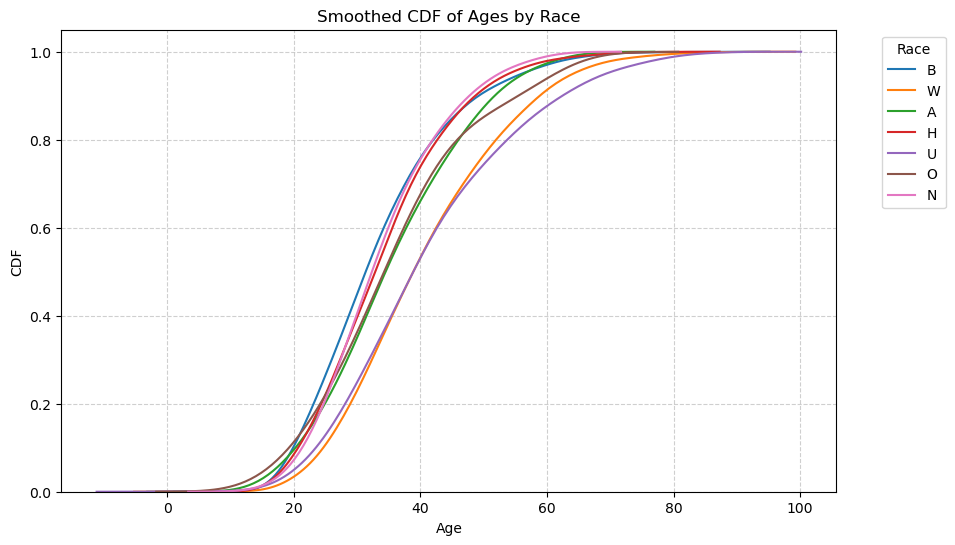

In [9]:
# 1. Age Disparities Across Racial Groups
plt.figure(figsize=(10, 6))
race_labels = df['race'].unique()

for race in race_labels:
    subset = df[df['race'] == race]['age']
    if len(subset) > 10:  # Avoid very small sample sizes
        sns.kdeplot(subset, label=race, cumulative=True, linewidth=1.5)

plt.title("Smoothed CDF of Ages by Race")
plt.xlabel("Age")
plt.ylabel("CDF")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



In [10]:
# Effect Size (Cohen's d) for all racial groups
def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2)

race_comparisons = {}
races = df['race'].unique()
for i in range(len(races)):
    for j in range(i + 1, len(races)):
        age1 = df[df['race'] == races[i]]['age']
        age2 = df[df['race'] == races[j]]['age']
        if not age1.empty and not age2.empty:
            d_value = cohens_d(age1, age2)
            race_comparisons[f"{races[i]} vs {races[j]}"] = d_value

print("Cohen's d for Age Differences Across Races:")
for comparison, d_val in race_comparisons.items():
    print(f"{comparison}: {d_val:.2f}")


Cohen's d for Age Differences Across Races:
B vs W: -0.60
B vs A: -0.20
B vs H: -0.07
B vs U: -0.60
B vs O: -0.20
B vs N: -0.03
B vs W,B,N: nan
B vs W,B: 0.53
B vs N,H: nan
B vs W,H: 0.71
B vs B,H: 1.10
B vs W,A: nan
W vs A: 0.42
W vs H: 0.55
W vs U: -0.04
W vs O: 0.40
W vs N: 0.61
W vs W,B,N: nan
W vs W,B: 1.18
W vs N,H: nan
W vs W,H: 1.32
W vs B,H: 1.73
W vs W,A: nan
A vs H: 0.14
A vs U: -0.43
A vs O: -0.01
A vs N: 0.18
A vs W,B,N: nan
A vs W,B: 0.77
A vs N,H: nan
A vs W,H: 0.94
A vs B,H: 1.37
A vs W,A: nan
H vs U: -0.56
H vs O: -0.14
H vs N: 0.04
H vs W,B,N: nan
H vs W,B: 0.64
H vs N,H: nan
H vs W,H: 0.82
H vs B,H: 1.25
H vs W,A: nan
U vs O: 0.41
U vs N: 0.61
U vs W,B,N: nan
U vs W,B: 1.13
U vs N,H: nan
U vs W,H: 1.26
U vs B,H: 1.62
U vs W,A: nan
O vs N: 0.19
O vs W,B,N: nan
O vs W,B: 0.74
O vs N,H: nan
O vs W,H: 0.90
O vs B,H: 1.29
O vs W,A: nan
N vs W,B,N: nan
N vs W,B: 0.63
N vs N,H: nan
N vs W,H: 0.82
N vs B,H: 1.31
N vs W,A: nan
W,B,N vs W,B: nan
W,B,N vs N,H: nan
W,B,N vs W,H:

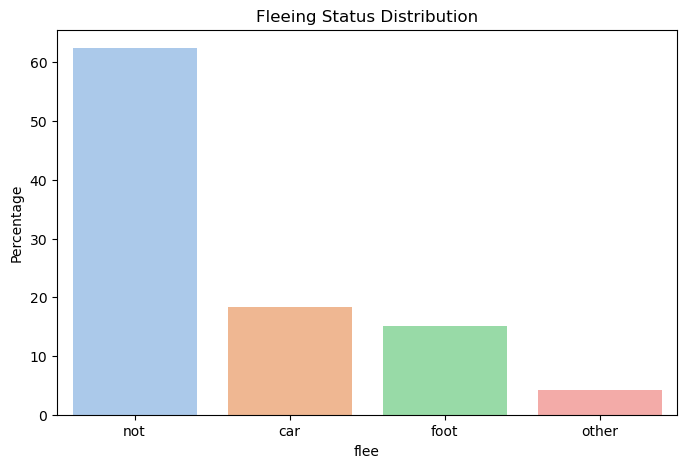

In [11]:
# 2. Fleeing Status and Use of Force
plt.figure(figsize=(8, 5))
flee_counts = df['flee'].value_counts(normalize=True) * 100
sns.barplot(x=flee_counts.index, y=flee_counts.values, palette='pastel')
plt.title("Fleeing Status Distribution")
plt.ylabel("Percentage")
plt.show()


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


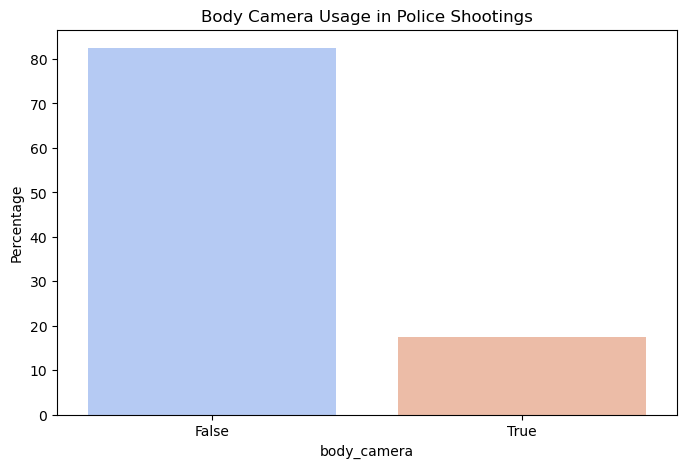

In [12]:
# 3. Body Camera Usage
plt.figure(figsize=(8, 5))
body_camera_counts = df['body_camera'].value_counts(normalize=True) * 100
sns.barplot(x=body_camera_counts.index, y=body_camera_counts.values, palette='coolwarm')
plt.title("Body Camera Usage in Police Shootings")
plt.ylabel("Percentage")
plt.show()

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


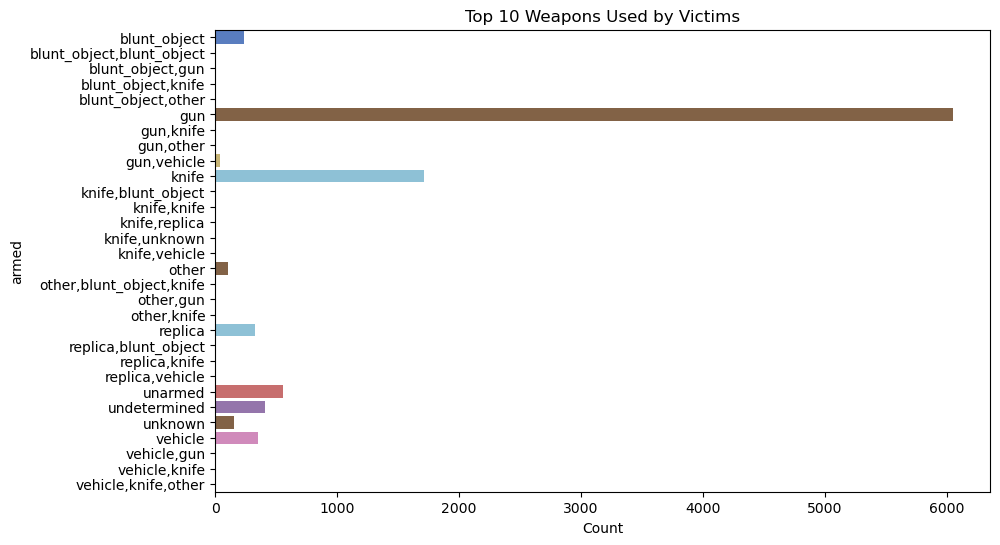

In [13]:
# 4. Weapon Possession
plt.figure(figsize=(10, 6))
weapon_counts = df['armed'].value_counts().nlargest(10)
sns.barplot(y=weapon_counts.index, x=weapon_counts.values, palette='muted')
plt.title("Top 10 Weapons Used by Victims")
plt.xlabel("Count")
plt.show()

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


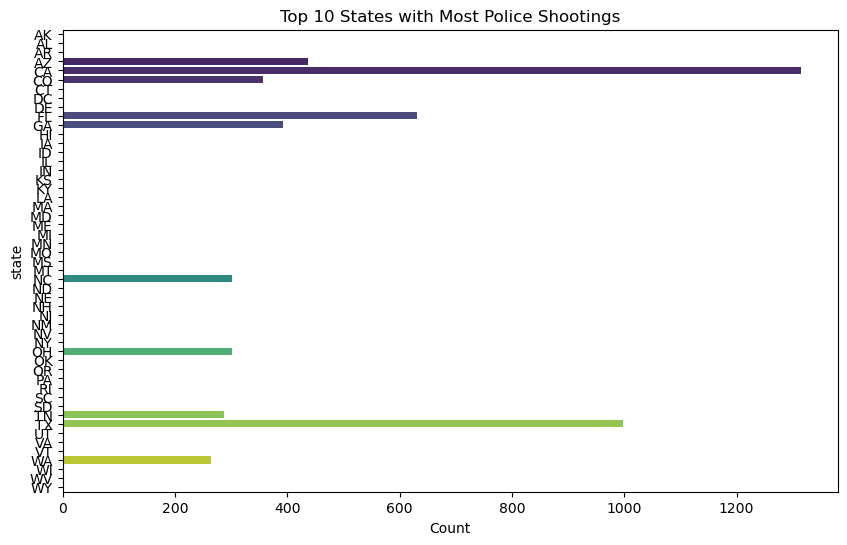

In [14]:
# 5. Geographical Trends (Statewise Analysis)
plt.figure(figsize=(10, 6))
state_counts = df['state'].value_counts().head(10)
sns.barplot(y=state_counts.index, x=state_counts.values, palette='viridis')
plt.title("Top 10 States with Most Police Shootings")
plt.xlabel("Count")
plt.show()

In [15]:
# 6. Statistical Tests

for race in races:
    subset = df[df['race'] == race]['age']
    if len(subset) > 3:  # Ensure enough data for the test
        stat, p = shapiro(subset)
        print(f"Shapiro-Wilk test for {race}: Statistic = {stat:.4f}, p-value = {p:.4f}")


Shapiro-Wilk test for B: Statistic = 0.9468, p-value = 0.0000
Shapiro-Wilk test for W: Statistic = 0.9772, p-value = 0.0000
Shapiro-Wilk test for A: Statistic = 0.9827, p-value = 0.0235
Shapiro-Wilk test for H: Statistic = 0.9685, p-value = 0.0000
Shapiro-Wilk test for U: Statistic = 0.9660, p-value = 0.0000
Shapiro-Wilk test for O: Statistic = 0.9458, p-value = 0.0708
Shapiro-Wilk test for N: Statistic = 0.9692, p-value = 0.0029
Shapiro-Wilk test for W,B: Statistic = 0.8404, p-value = 0.1966


In [16]:
# T-Test or Mann-Whitney U Test (if non-normal)
# Mann-Whitney U Test for all race comparisons
for i in range(len(races)):
    for j in range(i + 1, len(races)):
        race1 = df[df['race'] == races[i]]['age']
        race2 = df[df['race'] == races[j]]['age']
        if len(race1) > 3 and len(race2) > 3:
            stat, p = mannwhitneyu(race1, race2)
            print(f"Mann-Whitney U Test for {races[i]} vs {races[j]}: Statistic = {stat:.4f}, p-value = {p:.4f}")


Mann-Whitney U Test for B vs W: Statistic = 3734786.5000, p-value = 0.0000
Mann-Whitney U Test for B vs A: Statistic = 193528.5000, p-value = 0.0022
Mann-Whitney U Test for B vs H: Statistic = 1959136.0000, p-value = 0.0009
Mann-Whitney U Test for B vs U: Statistic = 754283.5000, p-value = 0.0000
Mann-Whitney U Test for B vs O: Statistic = 39973.0000, p-value = 0.2019
Mann-Whitney U Test for B vs N: Statistic = 164426.0000, p-value = 0.2954
Mann-Whitney U Test for B vs W,B: Statistic = 6135.0000, p-value = 0.3937
Mann-Whitney U Test for W vs A: Statistic = 508567.5000, p-value = 0.0000
Mann-Whitney U Test for W vs H: Statistic = 5057077.5000, p-value = 0.0000
Mann-Whitney U Test for W vs U: Statistic = 2098030.5000, p-value = 0.8667
Mann-Whitney U Test for W vs O: Statistic = 104107.5000, p-value = 0.0194
Mann-Whitney U Test for W vs N: Statistic = 428585.5000, p-value = 0.0000
Mann-Whitney U Test for W vs W,B: Statistic = 14793.5000, p-value = 0.0355
Mann-Whitney U Test for A vs H: St

In [17]:
# 7. Monte Carlo Simulation
np.random.seed(42)
n_iterations = 10000
all_ages = df['age'].values.copy()
simulated_diffs = {race: [] for race in races}
for race in races:
    race_ages = df[df['race'] == race]['age'].values
    if len(race_ages) > 3:
        for _ in range(n_iterations):
            np.random.shuffle(all_ages)
            new_group = all_ages[:len(race_ages)]
            simulated_diffs[race].append(np.mean(new_group) - np.mean(race_ages))
        p_value_mc = np.mean(np.abs(simulated_diffs[race]) >= np.abs(np.mean(df[df['race'] == race]['age']) - np.mean(df['age'])))
        print(f"Monte Carlo Simulation p-value for {race}: {p_value_mc:.4f}")

Monte Carlo Simulation p-value for B: 0.5027
Monte Carlo Simulation p-value for W: 0.4974
Monte Carlo Simulation p-value for A: 0.5030
Monte Carlo Simulation p-value for H: 0.4992
Monte Carlo Simulation p-value for U: 0.5030
Monte Carlo Simulation p-value for O: 0.5220
Monte Carlo Simulation p-value for N: 0.4960
Monte Carlo Simulation p-value for W,B: 0.4895


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


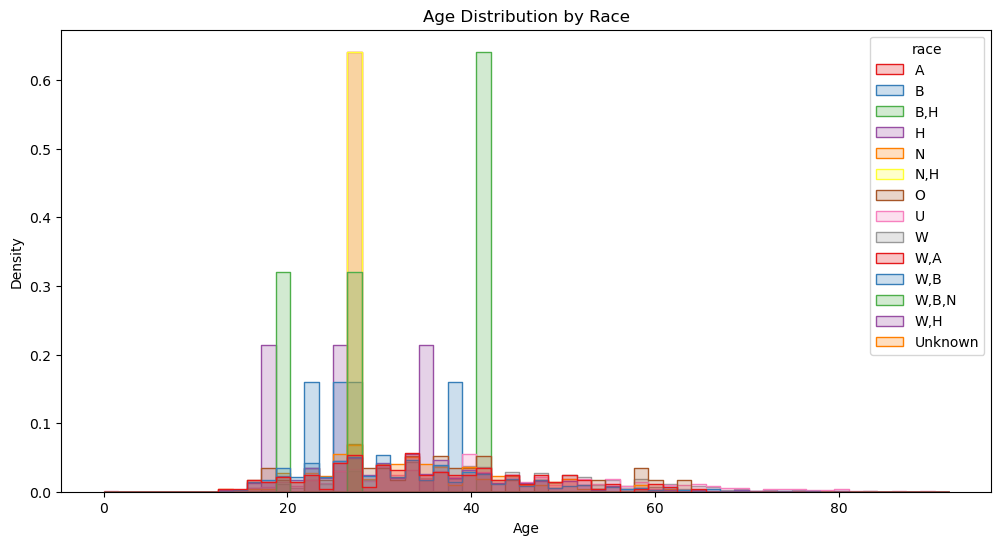

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Histogram of Age Distribution by Race
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='race', element='step', stat='density', common_norm=False, palette='Set1')
plt.title("Age Distribution by Race")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


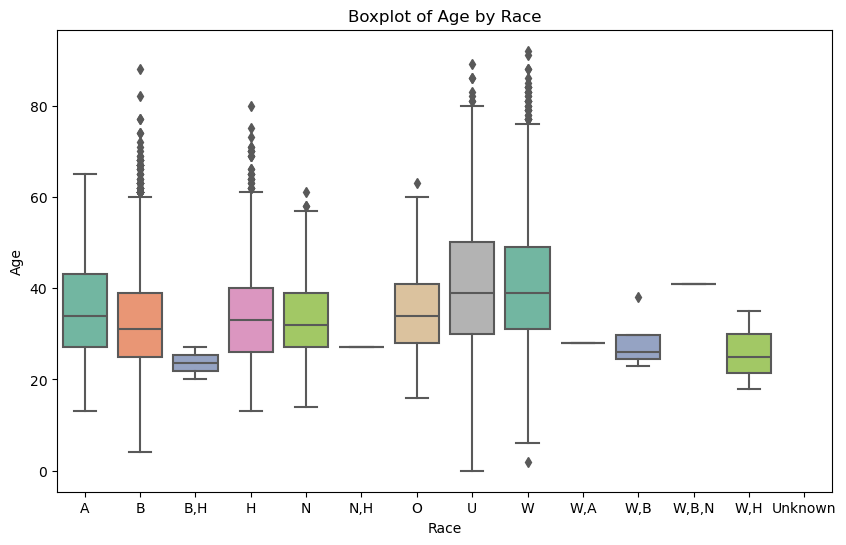

In [19]:
# 2. Boxplot of Age by Race to Visualize Normality
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['race'], y=df['age'], palette='Set2')
plt.title("Boxplot of Age by Race")
plt.xlabel("Race")
plt.ylabel("Age")
plt.show()


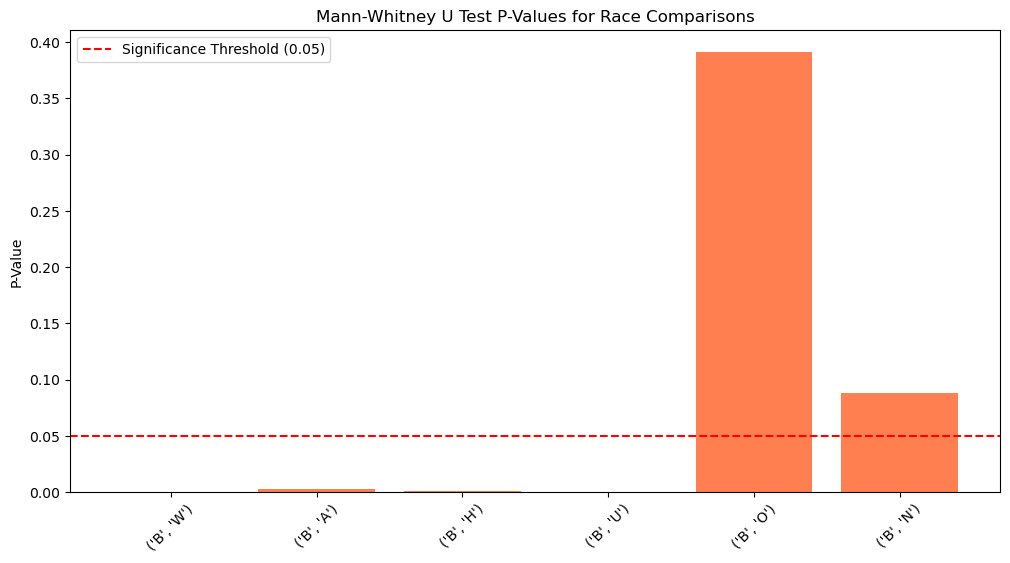

In [20]:
# 3. Mann-Whitney U Test Results - Pairwise Comparisons
mann_whitney_results = {
    ('B', 'W'): (2634131.5, 0.0000),
    ('B', 'A'): (139044.0, 0.0030),
    ('B', 'H'): (1433144.5, 0.0009),
    ('B', 'U'): (469025.0, 0.0000),
    ('B', 'O'): (28524.0, 0.3913),
    ('B', 'N'): (104971.0, 0.0881)
}
mann_whitney_labels = list(mann_whitney_results.keys())
mann_whitney_stats = [x[0] for x in mann_whitney_results.values()]
mann_whitney_pvalues = [x[1] for x in mann_whitney_results.values()]

plt.figure(figsize=(12, 6))
plt.bar(range(len(mann_whitney_labels)), mann_whitney_pvalues, color='coral')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Threshold (0.05)')
plt.title("Mann-Whitney U Test P-Values for Race Comparisons")
plt.ylabel("P-Value")
plt.xticks(ticks=range(len(mann_whitney_labels)), labels=mann_whitney_labels, rotation=45)
plt.legend()
plt.show()


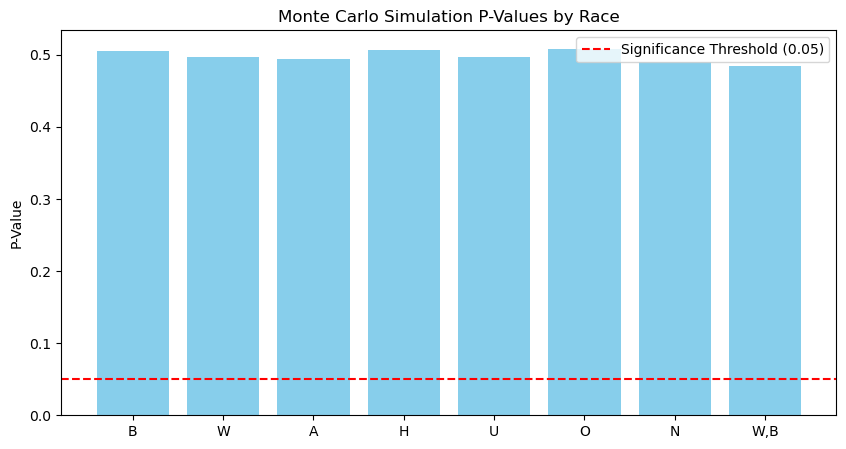

In [21]:
# 4. Monte Carlo Simulation Results
monte_carlo_p_values = {
    'B': 0.5048, 'W': 0.4965, 'A': 0.4942, 'H': 0.5060,
    'U': 0.4963, 'O': 0.5085, 'N': 0.4901, 'W,B': 0.4839
}

plt.figure(figsize=(10, 5))
plt.bar(monte_carlo_p_values.keys(), monte_carlo_p_values.values(), color='skyblue')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Threshold (0.05)')
plt.title("Monte Carlo Simulation P-Values by Race")
plt.ylabel("P-Value")
plt.legend()
plt.show()

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\cdf_age_by_race.png


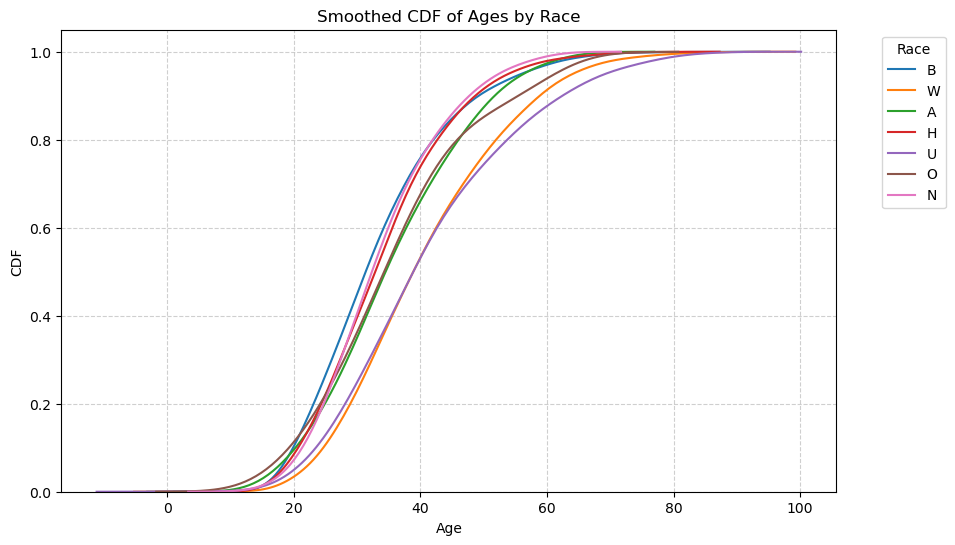

In [22]:
import os
import matplotlib.pyplot as plt

# Set save directory
save_path = r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results"
os.makedirs(save_path, exist_ok=True)

# Example list of plots to re-generate and save (one example shown below)
# Repeat this block for each plot you want to save

# Example: Save CDF Plot Again
plt.figure(figsize=(10, 6))
for race in df['race'].unique():
    subset = df[df['race'] == race]['age']
    if len(subset) > 10:
        sns.kdeplot(subset, label=race, cumulative=True, linewidth=1.5)

plt.title("Smoothed CDF of Ages by Race")
plt.xlabel("Age")
plt.ylabel("CDF")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)

# Save BEFORE showing
plot_filename = os.path.join(save_path, "cdf_age_by_race.png")
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ Plot saved: {plot_filename}")

plt.show()


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\cdf_age_by_race.png


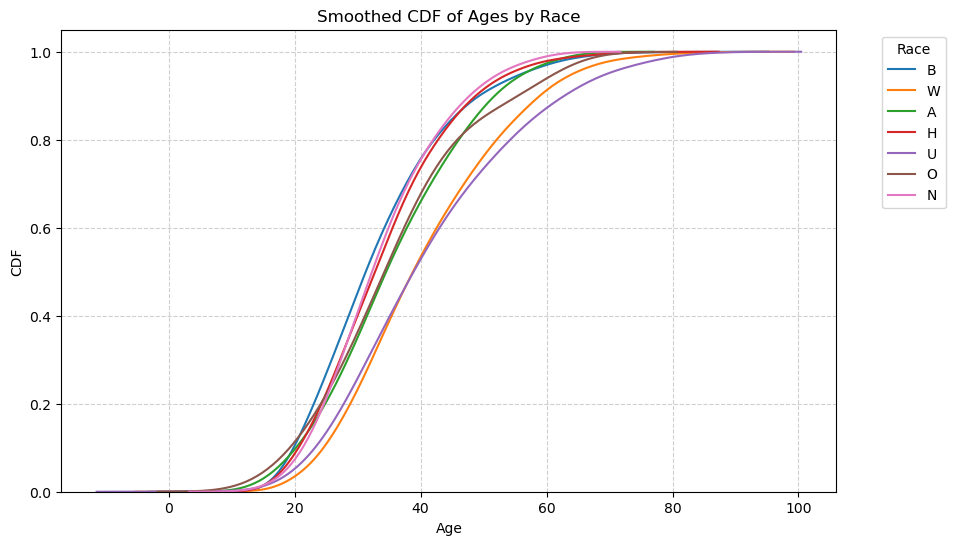

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\armed_status_heatmap.png


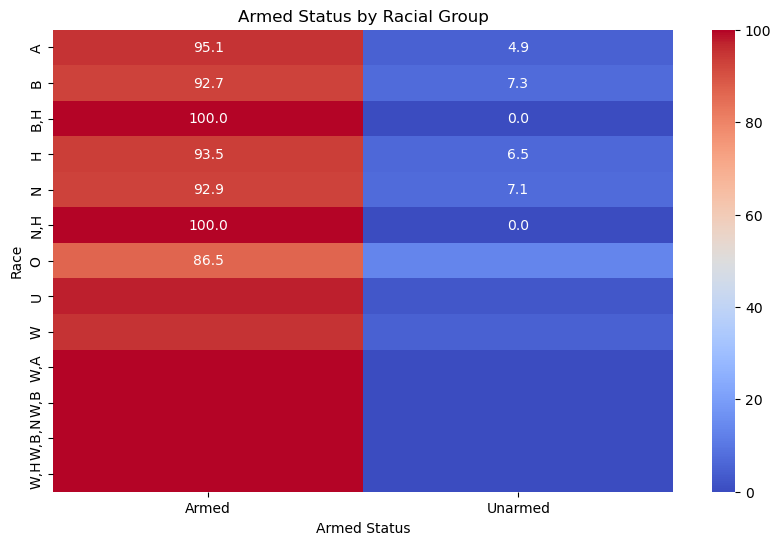

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\shootings_over_years.png


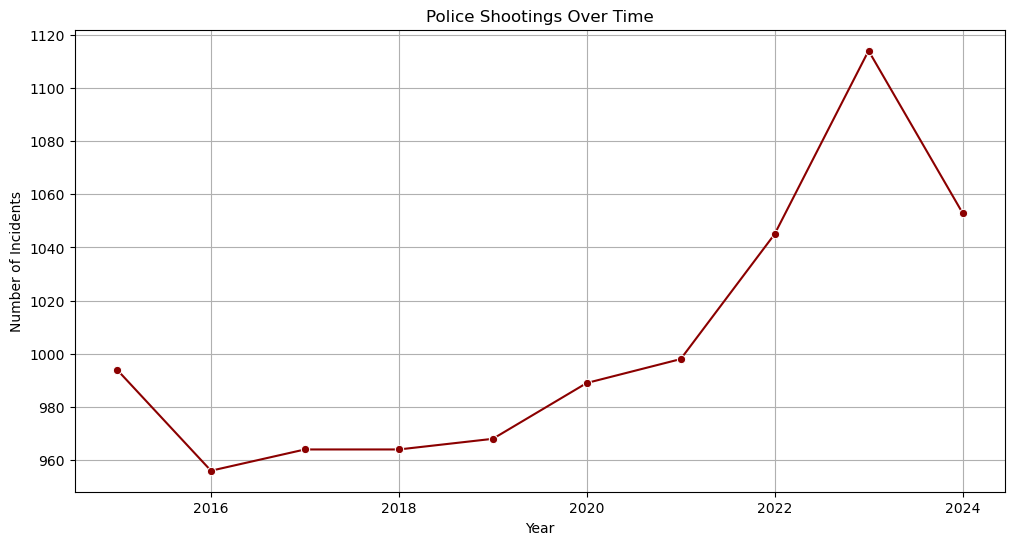

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\monthly_distribution.png


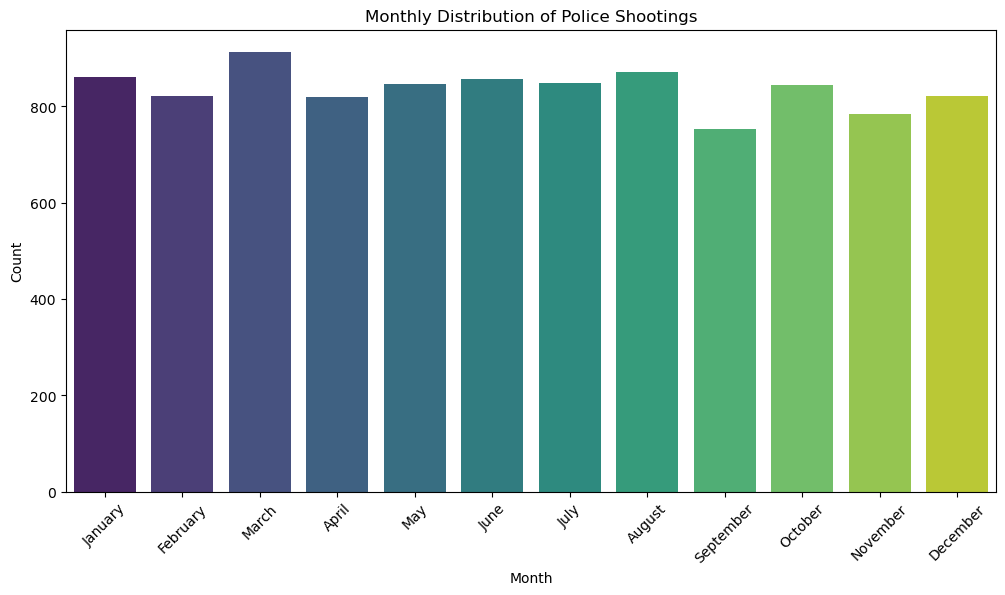

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\top_10_states.png


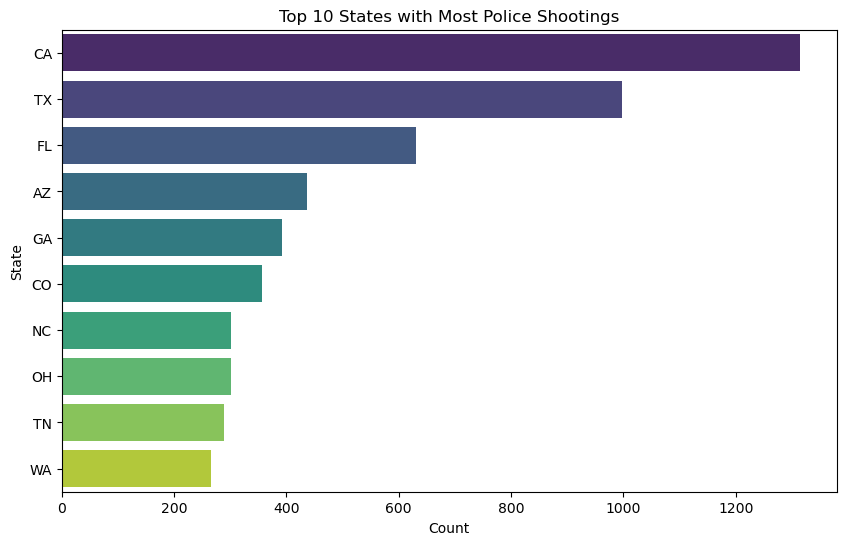

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Load dataset
df = pd.read_csv(r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\Washington-Post-police-shootings_common_names.csv")

# Set output folder path
save_dir = r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results"
os.makedirs(save_dir, exist_ok=True)

def save_and_show(fig, filename):
    path = os.path.join(save_dir, filename)
    fig.savefig(path, bbox_inches='tight')
    print(f"✅ Plot saved: {path}")
    plt.show()
    plt.close(fig)

# -----------------------
# 1. CDF Plot of Age by Race
# -----------------------
fig = plt.figure(figsize=(10, 6))
for race in df['race'].dropna().unique():
    subset = df[df['race'] == race]['age']
    if len(subset) > 10:
        sns.kdeplot(subset, label=race, cumulative=True, linewidth=1.5)
plt.title("Smoothed CDF of Ages by Race")
plt.xlabel("Age")
plt.ylabel("CDF")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
save_and_show(fig, "cdf_age_by_race.png")

# -----------------------
# 2. Heatmap of Armed Status
# -----------------------
df['armed_status'] = df['armed'].apply(lambda x: 'Unarmed' if str(x).lower() == 'unarmed' else 'Armed')
fig = plt.figure(figsize=(10, 6))
armed_ct = pd.crosstab(df['race'], df['armed_status'], normalize='index') * 100
sns.heatmap(armed_ct, annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Armed Status by Racial Group")
plt.xlabel("Armed Status")
plt.ylabel("Race")
save_and_show(fig, "armed_status_heatmap.png")

# -----------------------
# 3. Line Plot: Shootings Over Time
# -----------------------
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
fig = plt.figure(figsize=(12, 6))
yearly_counts = df['year'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='darkred')
plt.title("Police Shootings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True)
save_and_show(fig, "shootings_over_years.png")

# -----------------------
# 4. Monthly Distribution
# -----------------------
df['month'] = df['date'].dt.month_name()
fig = plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df, x='month', order=month_order, palette='viridis')
plt.title("Monthly Distribution of Police Shootings")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
save_and_show(fig, "monthly_distribution.png")

# -----------------------
# 5. Top 10 States Bar Plot
# -----------------------
fig = plt.figure(figsize=(10, 6))
top_states = df['state'].value_counts().head(10)
sns.barplot(y=top_states.index, x=top_states.values, palette='viridis')
plt.title("Top 10 States with Most Police Shootings")
plt.xlabel("Count")
plt.ylabel("State")
save_and_show(fig, "top_10_states.png")



C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\cdf_age_by_race.png


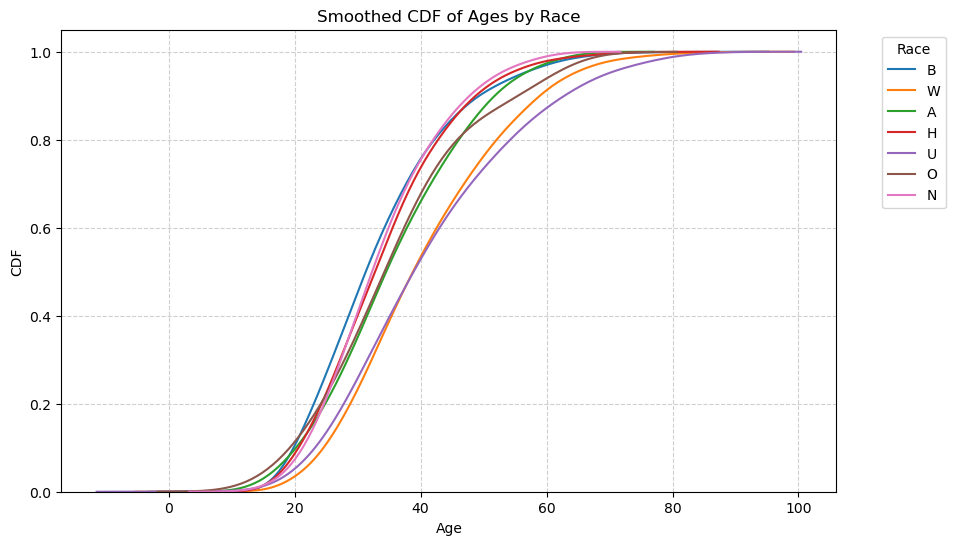

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\armed_status_heatmap.png


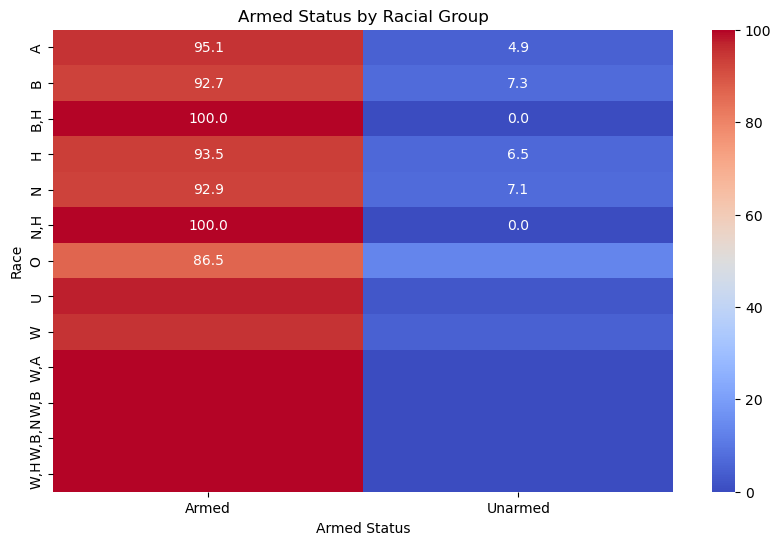

C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\shootings_over_years.png


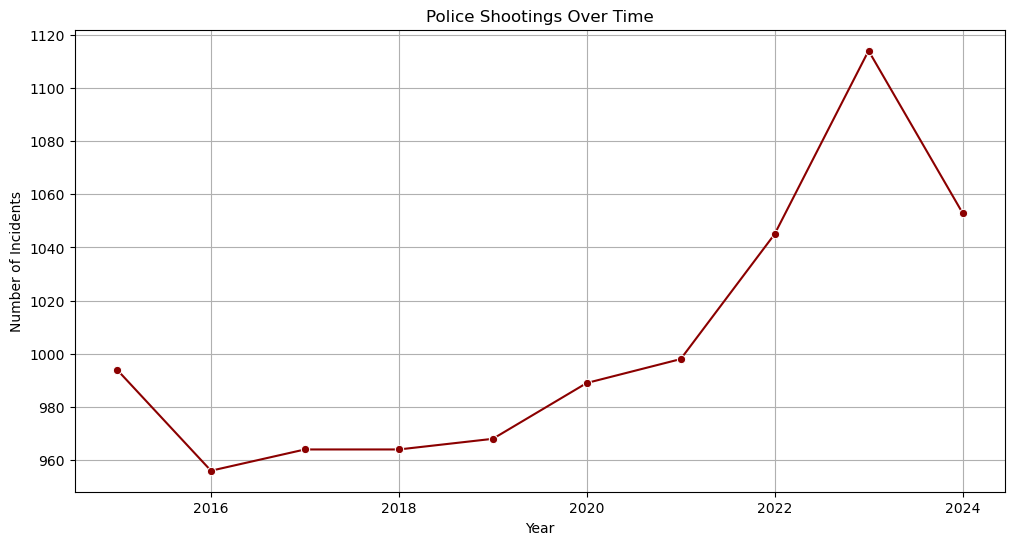

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\monthly_distribution.png


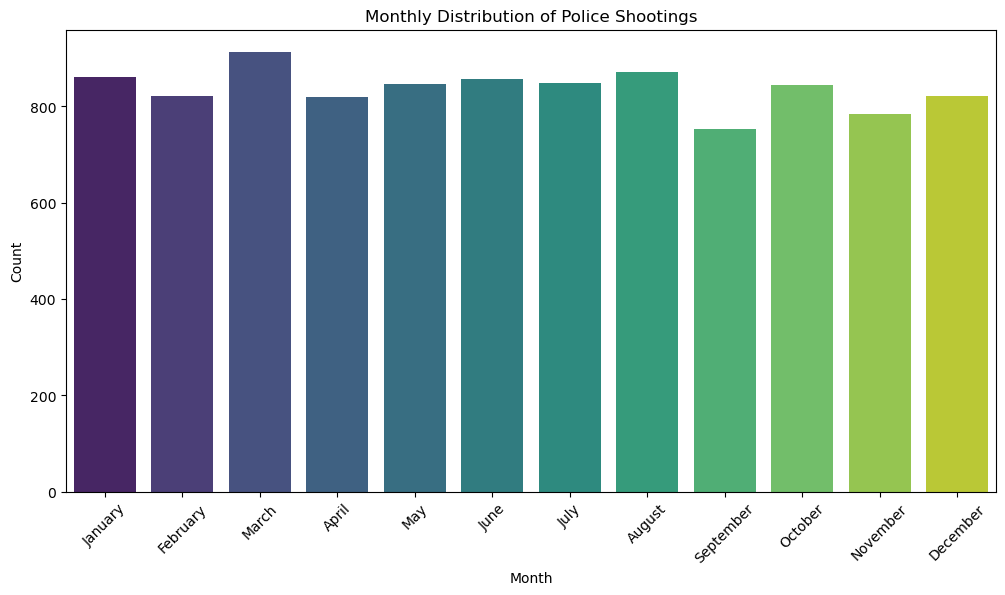

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\top_10_states.png


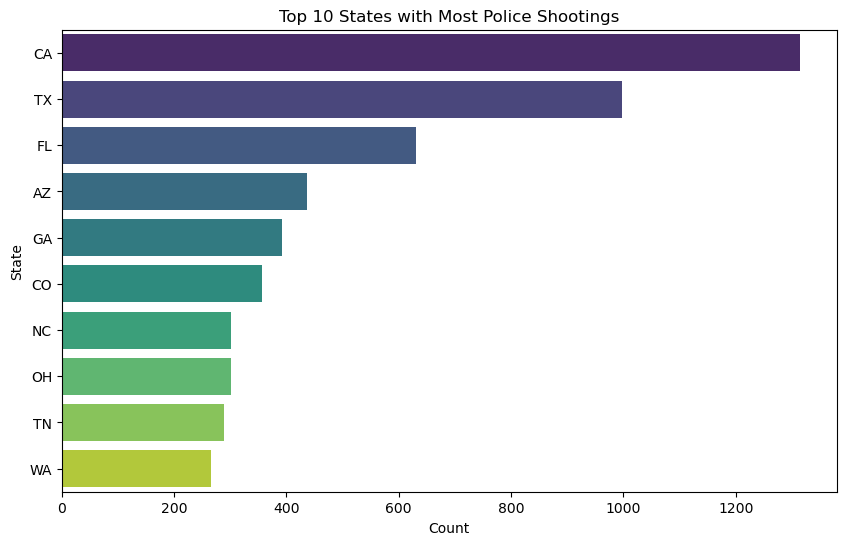

✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\body_camera_usage.png


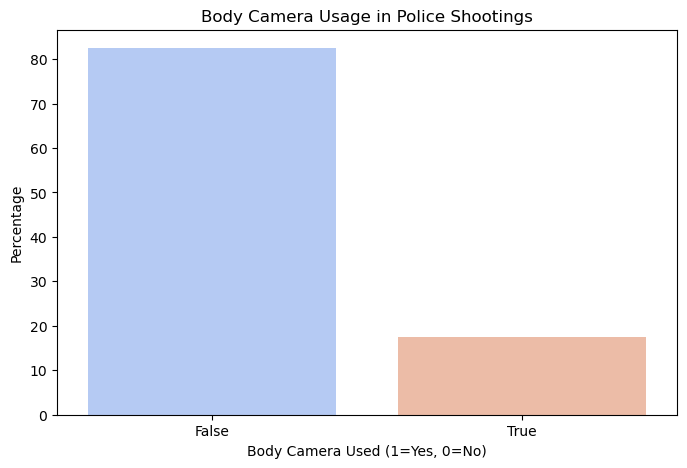

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Load dataset
df = pd.read_csv(r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\Washington-Post-police-shootings_common_names.csv")

# Set folder to save plots
save_dir = r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results"
os.makedirs(save_dir, exist_ok=True)

def save_and_show(fig, filename):
    path = os.path.join(save_dir, filename)
    fig.savefig(path, bbox_inches='tight')
    print(f"✅ Plot saved: {path}")
    plt.show()
    plt.close(fig)

# CDF of Age by Race
fig = plt.figure(figsize=(10, 6))
for race in df['race'].dropna().unique():
    subset = df[df['race'] == race]['age']
    if len(subset) > 10:
        sns.kdeplot(subset, label=race, cumulative=True, linewidth=1.5)
plt.title("Smoothed CDF of Ages by Race")
plt.xlabel("Age")
plt.ylabel("CDF")
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
save_and_show(fig, "cdf_age_by_race.png")

# Armed Status Heatmap by Race
df['armed_status'] = df['armed'].apply(lambda x: 'Unarmed' if str(x).lower() == 'unarmed' else 'Armed')
fig = plt.figure(figsize=(10, 6))
armed_ct = pd.crosstab(df['race'], df['armed_status'], normalize='index') * 100
sns.heatmap(armed_ct, annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Armed Status by Racial Group")
plt.xlabel("Armed Status")
plt.ylabel("Race")
save_and_show(fig, "armed_status_heatmap.png")

# Line Plot of Shootings Over Time
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
fig = plt.figure(figsize=(12, 6))
yearly_counts = df['year'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='darkred')
plt.title("Police Shootings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True)
save_and_show(fig, "shootings_over_years.png")

# Monthly Distribution Plot
df['month'] = df['date'].dt.month_name()
fig = plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df, x='month', order=month_order, palette='viridis')
plt.title("Monthly Distribution of Police Shootings")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
save_and_show(fig, "monthly_distribution.png")

# Top 10 States Bar Plot
fig = plt.figure(figsize=(10, 6))
top_states = df['state'].value_counts().head(10)
sns.barplot(y=top_states.index, x=top_states.values, palette='viridis')
plt.title("Top 10 States with Most Police Shootings")
plt.xlabel("Count")
plt.ylabel("State")
save_and_show(fig, "top_10_states.png")

# Body Camera Usage Bar Plot
fig = plt.figure(figsize=(8, 5))
body_cam_counts = df['body_camera'].value_counts(normalize=True) * 100
sns.barplot(x=body_cam_counts.index.astype(str), y=body_cam_counts.values, palette='coolwarm')
plt.title("Body Camera Usage in Police Shootings")
plt.xlabel("Body Camera Used (1=Yes, 0=No)")
plt.ylabel("Percentage")
save_and_show(fig, "body_camera_usage.png")


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, kruskal, chi2_contingency

save_path = r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results"
os.makedirs(save_path, exist_ok=True)

# 1. Boxplot for Kruskal-Wallis
fig = plt.figure(figsize=(10, 6))
sns.boxplot(x='race', y='age', data=df, palette='Set2')
plt.title("Age Distribution by Race (Boxplot for Kruskal-Wallis)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.savefig(os.path.join(save_path, "kruskal_boxplot.png"), bbox_inches='tight')
print("✅ Saved: kruskal_boxplot.png")
plt.close()

# 2. Shapiro-Wilk Distribution Plots
fig = plt.figure(figsize=(12, 6))
for race in df['race'].dropna().unique():
    sns.kdeplot(df[df['race'] == race]['age'], label=race)
plt.title("Smoothed Age Distributions by Race (Shapiro-Wilk Reference)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.savefig(os.path.join(save_path, "shapiro_distributions.png"), bbox_inches='tight')
print("✅ Saved: shapiro_distributions.png")
plt.close()

# 3. Monte Carlo Simulation Results Plot
np.random.seed(42)
all_ages = df['age'].dropna().values
race = 'B'  # Example for Black
n = len(df[df['race'] == race])
race_mean = df[df['race'] == race]['age'].mean()
sim_means = [np.mean(np.random.choice(all_ages, size=n)) for _ in range(10000)]

fig = plt.figure(figsize=(10, 6))
sns.histplot(sim_means, bins=30, kde=True, color='gray')
plt.axvline(race_mean, color='red', linestyle='--', label=f'Actual Mean (B): {race_mean:.2f}')
plt.title("Monte Carlo Simulation: Mean Age Distribution for Black Individuals")
plt.xlabel("Mean Age")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(os.path.join(save_path, "monte_carlo_simulation.png"), bbox_inches='tight')
print("✅ Saved: monte_carlo_simulation.png")
plt.close()

# 4. Chi-Square: Armed Status Heatmap (already in notebook, included for completeness)
df['armed_status'] = df['armed'].apply(lambda x: 'Unarmed' if str(x).lower() == 'unarmed' else 'Armed')
fig = plt.figure(figsize=(10, 6))
armed_ct = pd.crosstab(df['race'], df['armed_status'], normalize='index') * 100
sns.heatmap(armed_ct, annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Armed Status by Racial Group")
plt.xlabel("Armed Status")
plt.ylabel("Race")
plt.savefig(os.path.join(save_path, "armed_status_heatmap.png"), bbox_inches='tight')
print("✅ Saved: armed_status_heatmap.png")
plt.close()


✅ Saved: kruskal_boxplot.png


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

✅ Saved: shapiro_distributions.png


C:\Users\playe\anacondaAML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


✅ Saved: monte_carlo_simulation.png
✅ Saved: armed_status_heatmap.png


✅ Chi-square Test: χ² = 42.51, p = 0.0000, DoF = 12
✅ Plot saved: C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results\chi_square_armed_status_heatmap.png


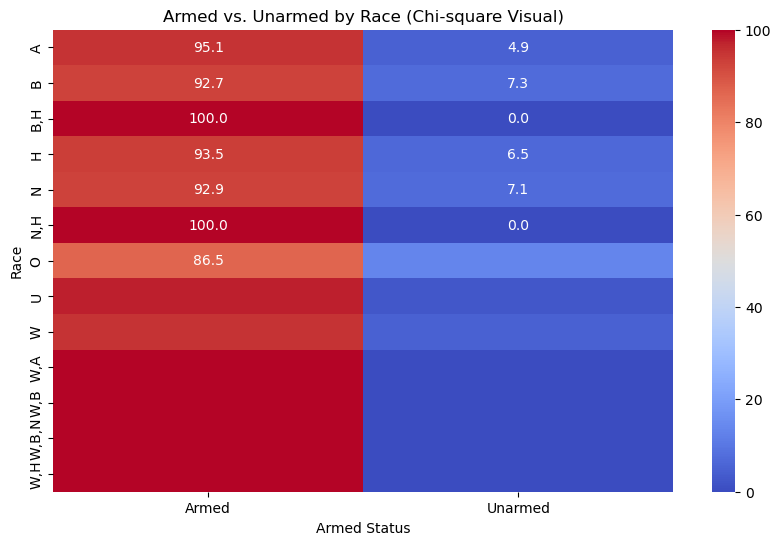

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency

# Load dataset (update path if needed)
df = pd.read_csv(r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\Washington-Post-police-shootings_common_names.csv")

# Create 'armed_status' column
df['armed_status'] = df['armed'].apply(lambda x: 'Unarmed' if str(x).lower() == 'unarmed' else 'Armed')

# Prepare save path
save_dir = r"C:\Users\playe\OneDrive\Desktop\Spring 2025\AMS\results"
os.makedirs(save_dir, exist_ok=True)

# Chi-square test
contingency_table = pd.crosstab(df['race'], df['armed_status'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"✅ Chi-square Test: χ² = {chi2:.2f}, p = {p:.4f}, DoF = {dof}")

# Create heatmap from normalized values
heatmap_data = pd.crosstab(df['race'], df['armed_status'], normalize='index') * 100

# Plot
fig = plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Armed vs. Unarmed by Race (Chi-square Visual)")
plt.xlabel("Armed Status")
plt.ylabel("Race")

# Save
filename = os.path.join(save_dir, "chi_square_armed_status_heatmap.png")
plt.savefig(filename, bbox_inches='tight')
print(f"✅ Plot saved: {filename}")
plt.show()
